In [5]:
import numpy as np
from cascadoc_new import build_hyp_system

# ----------------------------- постановка -----------------------------
G11_true = lambda t: -(10*np.sin(10*t))/(np.cos(10*t)+np.sin(15*t)+4)
G22_true = lambda t: -(15*np.cos(15*t))/(4-np.cos(10*t)-np.sin(15*t))

x0 = lambda s: 2*(s-1/2)**3+1/2
y0 = lambda s: 1/2

x_an = lambda s, t: 2*np.cos(10*t)*(s-1/2)**3+1/2
y_an = lambda s, t: 2*np.sin(15*t)*(s-1/2)**3+1/2

T = [0, 0.5]
S = [0, 1]
C = [1, 2]

D = lambda t: np.cos(10*t)**2 + np.sin(15*t)**2
B11 = lambda s, t: -(10*np.sin(10*t)*np.cos(10*t))/D(t)
B12 = lambda s, t: -(10*np.sin(10*t)*np.sin(15*t))/D(t)
B21 = lambda s, t:  (15*np.cos(15*t)*np.cos(10*t))/D(t)
B22 = lambda s, t:  (15*np.cos(15*t)*np.sin(15*t))/D(t)

G11 = lambda t: -(10*np.sin(10*t))/(np.cos(10*t)+np.sin(15*t)+4)
G12 = lambda t: G11(t)
G21 = lambda t: -(15*np.cos(15*t))/(4-np.cos(10*t)-np.sin(15*t))
G22 = lambda t: G21(t)

F1 = lambda s, t: -6*C[0]*np.cos(10*t)*(s-1/2)**2 - (B11(s, t)+B12(s, t))/2
F2 = lambda s, t:  6*C[1]*np.sin(15*t)*(s-1/2)**2 - (B21(s, t)+B22(s, t))/2

phi_dx = lambda s, x, y: -2*(x - x_an(s, T[1]))
phi_dy = lambda s, x, y: -2*(y - y_an(s, T[1]))

# ------------------------------ решение -------------------------------
sys, mesh, solver = build_hyp_system(
    S=(0, 1), T=(0, 0.5), C=(1, 2),
    B=(B11, B12, B21, B22), F=(F1, F2), G=((G11, G12), (G21, G22)),
    x0=x0, y0=y0, phi_dx=phi_dx, phi_dy=phi_dy,
    m=50,
)

sys.var_analytic('X_an', lambda p: np.array(
    [2*np.cos(10*p.t)*(p.s-1/2)**3+1/2, 
     2*np.sin(15*p.t)*(p.s-1/2)**3+1/2]), dim=2)


solver.solve_forward(mesh)   # X  (эквивалент solve_initial + solver_center + solver_final)
solver.solve_adjoint(mesh)   # PSI и p

# --------------------------- результаты -------------------------------
node = mesh.get_center_node(0, 0)
print(node.s, node.t, node['X'], node['PSI'])      # состояние и сопряжённое

nodes = mesh.get_border(type_border="final", sort_s=True)   # срез при t = T1
s_final = np.array([nd.s for nd in nodes])
x_final = np.array([nd['X'][0] for nd in nodes])
y_final = np.array([nd['X'][1] for nd in nodes])
print("max|err| x:", np.max(np.abs(x_final - [x_an(s, T[1]) for s in s_final])))


0.5 0.25 [0.50005213 0.50014721] [-1.09603693  0.24644441]
max|err| x: 0.0025163780149046744


In [6]:
from cascadoc_new import Plotter

In [7]:
plot = Plotter(sys, mesh)

<Axes: title={'center': 's = 1'}, xlabel='t'>

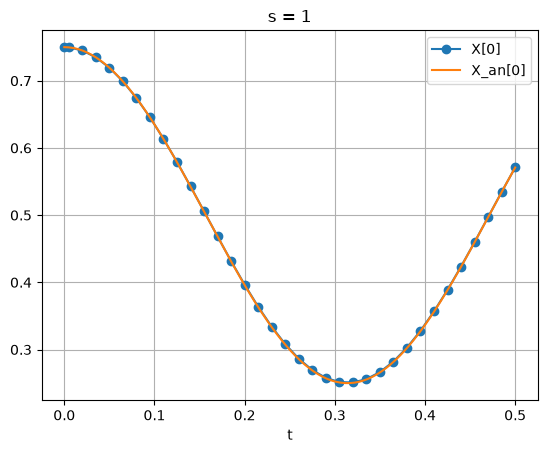

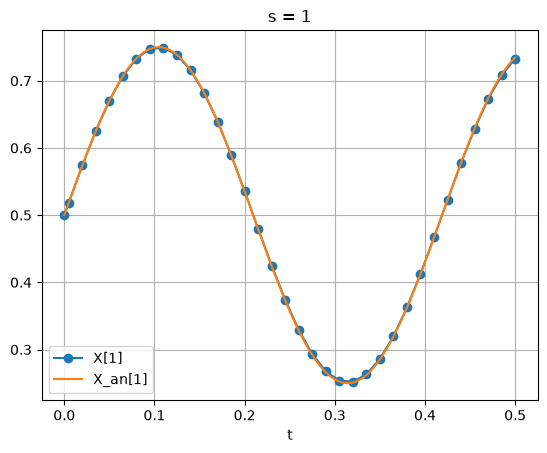

In [8]:
plot.plot_slice([('X', 0), ('X_an', 0)], s = mesh.S1)
plot.plot_slice([('X', 1), ('X_an', 1)], s = mesh.S1)


<Axes3D: title={'center': 'X[1]'}, xlabel='s', ylabel='t', zlabel='X[1]'>

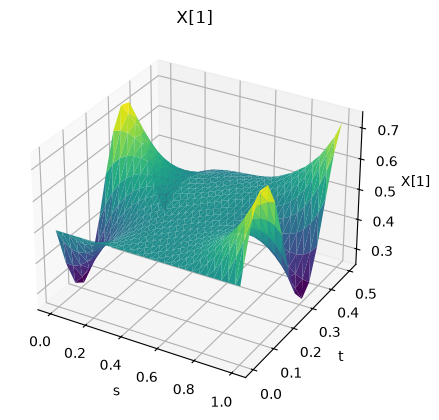

In [17]:
plot.plot_surface(('X', 1))

<Axes: title={'center': 't = 0.5'}, xlabel='s'>

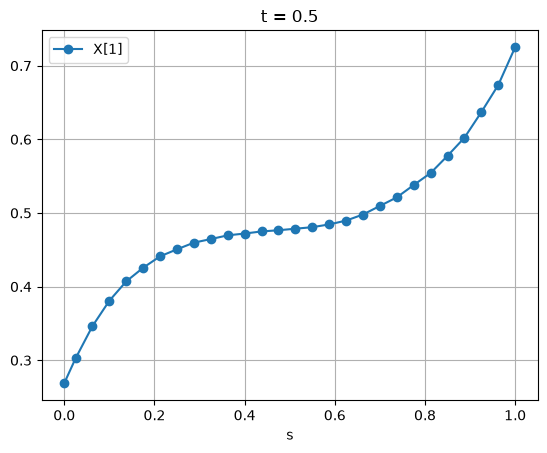

In [30]:
plot.plot_slice(('X', 1), t=mesh.T1 )